# COE311K Midterm Project (Vishnu Prasad)
## Introduction:

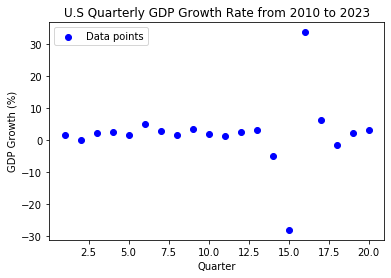

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Original data points
x = np.arange(1,21)
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

# Plot
plt.scatter(x, y, color='blue', label='Data points')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.title('U.S Quarterly GDP Growth Rate from 2010 to 2023')
plt.legend()
plt.show()

This scatter plot is the dataset provided by the U.S. Bureau of Economic Analysis, showcasing quarterly GDP growth from 2010 to 2023. 20 of the full 56 quarterly data points are included in the given dataset. We will be applying 3 methods to interpolate the rest of the data and perform trend analysis: cubic spline interpolation, polynomial fitting, and least squares linear regression.

## Part A — Cubic Spline Interpolation

In [2]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2*(h[i-1] + h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6*(((y[i + 1]-y[i])/h[i]) - (y[i] - y[i - 1]) / h[i - 1]) # Right-hand side vector
    return A, B, C, D

In [3]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [4]:
def evaluate_spline(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

Condition Number: 2.946179258376534


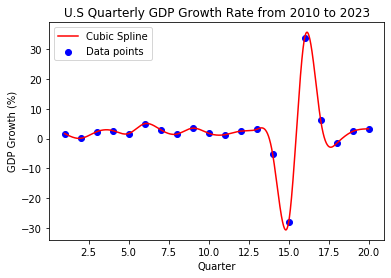

In [5]:
# Set up the tridiagonal matrix for the cubic spline
A, B, C, D = setup_tridiagonal_matrix(x, y)

# Determining condition number
m = len(B)
X = np.zeros((m, m)) 
np.fill_diagonal(X, B) # main diagonal
np.fill_diagonal(X[1:], A) # subdiagonal
np.fill_diagonal(X[:, 1:], C) # superdiagonal
condition = np.linalg.cond(X)
print(f'Condition Number: {condition}')

# Solving tridiagonal matrix
M = np.zeros(len(x)) # Endpoints are 0 for natural spline
M[1:-1] = thomas_algorithm(A, B, C, D)

# Evaluating spline in each interval
x_spline = np.arange(x[0], x[-1], 0.01)
y_spline = evaluate_spline(x, y, M, x_spline)

# Plot
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x_spline, y_spline, color = 'red', label = 'Cubic Spline')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.title('U.S Quarterly GDP Growth Rate from 2010 to 2023')
plt.legend()
plt.show()

1. To create the cubic spline interpolation, we first set up a system of equations that relates the second derivatives at each knot in the form of a tridiagonal matrix, using the Thomas algorithm to solve it. For 20 data points, there are 18 unknown second derivatives that the Thomas algorithm solves for to satisfy continuity conditions. The spline, as well as its first and second derivatives, must be continuous at each internal point to fulfill these conditions. To satisfy boundary conditions for a natural spline, the second derivatives at the endpoints are set to zero.

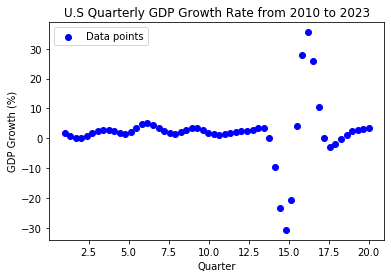

In [6]:
# Interpolating for in-between quarters
x_eval = np.linspace(x[0], x[-1], 56)
y_eval = evaluate_spline(x, y, M, x_eval)

# Plot
plt.scatter(x_eval, y_eval, color = 'blue', label = 'Data points')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.title('U.S Quarterly GDP Growth Rate from 2010 to 2023')
plt.legend()
plt.show()

2. The interpolant does appear visually smooth and while it is mathematically reasonable, it is questionable whether the interpolant is economically reasonable close to outlying data points such as 2020 Q2 and 2020 Q3. Since cubic splines are not robust to noise, interpolated GDP growth data near them may not be accurate due to oscillations in the predicted data.

3. Due to significant outliers in 2020 Q2 and 2020 Q3, extreme oscillations occur near this area. Since cubic splines must pass through every point, numerical stability is sacrificed in favor of exact interpolation. This behavior is similar to Runge's phenomenon, where interpolations of data with large variations can cause oscillations, even when cubic splines generally do well to mitigate this phenomenon compared to high-degree polynomials. A weighted least squares or smoothing splines model would be more preferable to minimize this effect, as they will resist error variances by preventing outliers from disproportionately influencing the fit. 

## Part B — Polynomial & Least Squares Comparison

In [7]:
def evaluateFit(y, y_pred):
    # Mean Squared Error (MSE)
    mse = np.mean((y - y_pred)**2)
    rmse = np.sqrt(mse)
    
    # R-squared value
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    return rmse, r_squared

Condition Number: 482958.7228348024


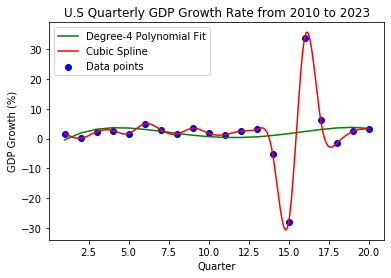

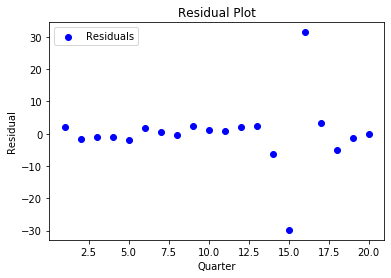

RMSE: 9.965326786519531, R^2: 0.016632392138784757


In [8]:
# Setting up Vandermonde matrix
degree = 4
V = np.vander(x, N=degree+1, increasing=True)
condition = np.linalg.cond(V)
print(f'Condition Number: {condition}')

VT_V = np.dot(V.T, V) # V.T * V
VT_y = np.dot(V.T, y) # V.T * y

# Solve for a (coefficients)
coefficients = np.linalg.solve(VT_V, VT_y)
y_poly = np.dot(V, coefficients)

# Plot
plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_poly, color='green', label=f'Degree-4 Polynomial Fit')
plt.plot(x_spline, y_spline, 'red', label = 'Cubic Spline')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.title('U.S Quarterly GDP Growth Rate from 2010 to 2023')
plt.legend()
plt.show()

# Residual plot
residuals = y - y_poly
plt.scatter(x, residuals, color = 'blue', label = 'Residuals')
plt.xlabel('Quarter')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.legend()
plt.show()

# Diagnostics
rmse, r_squared = evaluateFit(y, y_poly)
print(f'RMSE: {rmse}, R^2: {r_squared}')

1. The degree-4 polynomial is better at capturing the overall trend while the cubic spline is better at creating a piecewise function that connects every data point in the dataset. Interpolation focuses on agreement with the original data while approximation focuses on creating a more representative global trend, even if exactness is sacrificed. Similarly, cubic splines excel at interpolating from known data point to known data point, but it comes at the expense of accurate approximation if the data is noisy. The opposite is true for polynomial fitting curves.

In [9]:
def leastSquares(X, Y):
    n = len(X)
    sumXi = np.sum(X)
    sumYi = np.sum(Y)
    sumXiSquared = np.sum(X**2)
    sumXiYi = np.sum(X*Y)
    
    m = (n*sumXiYi - sumXi*sumYi)/(n*sumXiSquared - (sumXi**2))
    c = (sumYi - m*sumXi)/n
    
    return m, c

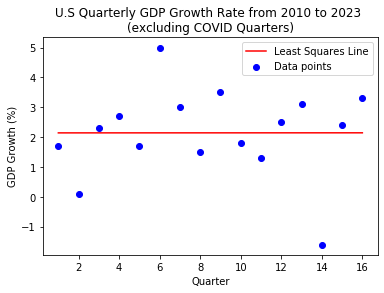

Slope: 0.00014705882352961238


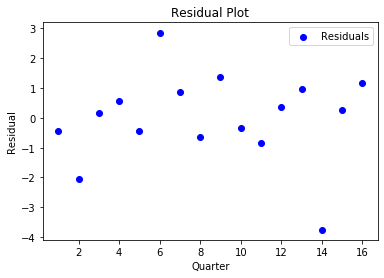

RMSE: 1.4435063137863915, R^2: 2.2054826087636314e-07


In [10]:
# Excluding COVID quarters
x_excluded = np.arange(1,17)
y_excluded = np.concatenate((y[:13], y[17:]))

# Solving least squares model
m, c = leastSquares(x_excluded, y_excluded)
y_linear = m*x_excluded + c

# Plot
plt.scatter(x_excluded, y_excluded, color = 'blue', label = 'Data points')
plt.plot(x_excluded, y_linear, color = 'red', label = 'Least Squares Line')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.title('U.S Quarterly GDP Growth Rate from 2010 to 2023 \n(excluding COVID Quarters)')
plt.legend()
plt.show()
print(f'Slope: {m}')

# Residual plot
residuals = y_excluded - y_linear
plt.scatter(x_excluded, residuals, color = 'blue', label = 'Residuals')
plt.xlabel('Quarter')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.legend()
plt.show()

# Diagnostics
rmse, r_squared = evaluateFit(y_excluded, y_linear)
print(f'RMSE: {rmse}, R^2: {r_squared}')

2. Since the R^2 value is near 0, a linear trend for this data does not seem to make sense as the best fit line doesn't explain any of the variance. A linear trend assumes that GDP growth changes at a constant rate over time, which is an oversimplification of the data since GDP growth is affected by numerous external economic factors such as business cycles and policy changes. Additionally, by removing data points from the COVID quarters, this model is implicitly based on the assumption that those quarters were not representative of the overall trend, which may bias the results since economic disruptions are not considered.

## Part C: — Method Justification

1. Assuming that the known data points are trustworthy, a cubic spline is better at interpolating data points between them. By using low-degree polynomial segments and ensuring continuity in first and second derivatives at interior knots, cubic splines are smoother than high-degree polynomial models by minimizing sharp oscillations (Runge's phenomenon). While both models are sensitive to outliers, an outlier in a polynomial model will skew the entire curve, while an outlier in a cubic spline model will only affect the segments immediately surrounding the outlier. Numerically, this is represented by how much larger the condition number of the Vandermonde matrix is compared to the tridiagonal matrix, (~3 vs ~5x10^5) meaning that the tridiagonal matrix is well-conditioned while the Vandermonde matrix is ill-conditioned. This suggests that cubic splines are much more numerically stable than polynomial curves. Therefore, for interpolation, a cubic spline is smoother, more stable, and more accurate than a polynomial fit.

2. Big O notation is used to represent how the computational cost of an algorithm scales with the number of inputs N. Cubic spline interpolation uses the Thomas algorithm which implements forward elimination and backwards substitution of a tridiagonal matrix, each with time complexity O(N), resulting in a total time complexity of O(N). On the other hand, polynomial fitting requires a Vandermonde matrix to be solved using Gaussian elimination, which has a time complexity of O(N^3). Since the number of data points in this dataset is small, the difference in computational cost is negligible. However, with enough economic data, cubic spline interpolation is much more efficient than polynomial fitting in terms of time complexity, so it does not change my final recommendation.

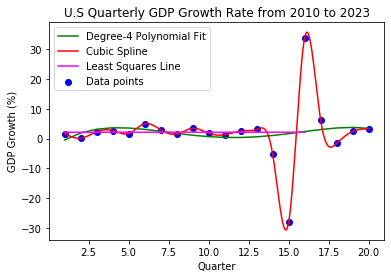

In [11]:
# Plotting all methods alongside each other
plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_poly, color='green', label=f'Degree-4 Polynomial Fit')
plt.plot(x_spline, y_spline, 'red', label = 'Cubic Spline')
plt.plot(x_excluded, y_linear, color = 'magenta', label = 'Least Squares Line')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.title('U.S Quarterly GDP Growth Rate from 2010 to 2023')
plt.legend()
plt.show()

## Conclusion:

We applied 3 methods to fit the GDP growth data: cubic spline interpolation, polynomial fitting, and least squares linear regression. Cubic spline interpolation proved to be the best method at interpolation because it is smooth, passes through every data point, and handles local variation well. However, a cubic spline is not robust to noise as it will pass through any outlier in the dataset, making it less useful for overall trend analysis. On the other hand, polynomial fits and linear regression are least squares methods, which allow them to smooth out noise more effectively than cubic splines. 

In terms of trend analysis, a polynomial fit can capture globally curved trends, but they are susceptible to overfitting and can cause Runge's phenomenon with higher order polynomials. On the other hand, linear regression is more stable and more interpretable from a constant slope, but can be an oversimplification for complex datasets with multiple external factors. It's important to note that these methods are meant for interpolation and struggle with extrapolation. Polynomials and cubic splines diverge rapidly outside the data range.

For this dataset, since there is no obvious global curvature in the data (disregarding COVID outliers), the linear regression model captured the overall trend better than the polynomial fit, although even the linear model could not explain much of the variance in the data, implying that GDP growth cannot be described well by a simple linear model. Overall, analyzing this data helped to highlight the tradeoffs must be made in algorithm choice to best fit the data depending on preference in interpolation or approximation.